In [141]:
#run the regressions for the clinical outcomes project - first for loading parameters, then on the CoM matrices
#load packages needed
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

#go to working directory
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')
data = loadmat('Clinical_Outcomes_Workspace.mat') #Load matlab workspace for importing variables 

# See what variables are inside
print(data.keys())

#load the loading parameters, clinical variables, and CoM data for regression
depind= data['depind'] #depression loading parameters for the regression analyses 
hcind = data['hcind'] #healthy control loading parameters just in case
age = data['age'] #age of depression group for regression analyses
Location_ID = data['Location_ID'] #site for regression analyses
sex_coded = data['sex_coded'] #sex variable for depressed subjects, categorical
all_matrices_dep = data['all_matrices_dep'] #depression CoM matrices
clean_labels = [lbl[0] for lbl in Labels]  #SPECT ICA component labels for the CoM matrices, converted from MATLAB and removes brackets and extra text in the string 
print(clean_labels) #do a check, the labels are showing up weird, make sure string conversion occurred

#sanity check on dims
print(depind.shape) #should be 2743 x 68; check loaded variable
print(hcind.shape) #should be 76 x 68; check loaded variable

/opt/anaconda3/lib/python3.13/site-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


dict_keys(['__header__', '__version__', '__globals__', 'Adjustment_Disorder', 'Alcohol_Related_Disorder', 'Amnestic_disorders', 'Amphetamine_Related_Disorder', 'Anorexia_Nervosa', 'Antisocial_Personality_Disorder', 'Anxiety_Disorder', 'Aspergers', 'Attention_Deficit_Disruptive_Behavior', 'Attention_Deficit_hyperactivity', 'Autism', 'Autonomic_HotCold_Flashes', 'Avoidant_Personality_Disorder', 'BSC_100_Having_dark_thoughts_ones_that_may_involve_suicidal_or_', 'BSC_101_Experiencing_periods_of_forgetfulness_or_memory_problem', 'BSC_10_Having_poor_planning_skills', 'BSC_11_Lacking_clear_goals_or_forward_thinking', 'BSC_12_Having_difficulty_expressing_feelings', 'BSC_13_Having_difficulty_expressing_empathy_for_others', 'BSC_14_Experiencing_excessive_daydreaming', 'BSC_15_Feeling_bored', 'BSC_16_Feeling_apathetic_or_unmotivated', 'BSC_17_Feeling_tired_sluggish_or_slow_moving', 'BSC_18_Feeling_spacey_or_in_a_fog', 'BSC_19_Feeling_fidgety_restless_or_trouble_sitting_still', 'BSC_1_Failing_to_g

In [78]:
#go to working directory and load data frame aka the .csv file
#load factor scores from this
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")
print(df.columns.tolist()) #print headers of each variable so I can load correctly
score_c_perc_think_score = df['score|c|perc|think.score'] #one of the factor analyzed scores
score_m_perc_mem_work_score = df['score|m|perc|mem-work.score'] #one of the factor analyzed scores

['CID', 'Location_ID', 'age', 'sex_coded', 'dx', 'conc_filename', 'rest_filename', 'Hallucinogen_related_disorders', 'Borderline', 'Eating_Disorder_unspecified', 'Passive_Aggressive_Personality_Disorder', 'Mood_Disorder_NOS', 'Amnestic_disorders', 'Opioid_Related_Disorder', 'SubstanceAbuseDisorder', 'Factitious_disorder', 'Elimination_Disorder', 'Aspergers', 'Cannabis_Related_Disorder', 'Toxicicity_Encephalopathy', 'frontotemporal_dementia', 'Depression_NOS', 'Dissociative_Disorder', 'Cocaine_Related_Disorder', 'Vascular_dementia', 'Somatoform_disorders', 'Depressive_Disorder', 'Personallity_Cluster_A', 'Amphetamine_Related_Disorder', 'Disruptive_Behavior', 'TemporalDysfunction', 'Mathematics_disorder', 'Bipolar_Disorder', 'Antisocial_Personality_Disorder', 'Caffeine_related_disorders', 'Schizoid_Personality_Disorder', 'Learning_Disorder', 'Personality_Disorder_NOS', 'dysgraphia', 'Nicotine_related_disorders', 'Polysubstance_related_disorder', 'BrainTrauma', 'Substance_dependence', 'Bu

In [140]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np

# Add each loading column to df
for i in range(68):
    df[f"loading_{i+1}"] = depind[:, i]

# Storage lists
pvals_c = []
Fvals_c = []
pvals_m = []
Fvals_m = []

for i in range(68):
    loading = f"loading_{i+1}"

    # ANCOVA model including both factor scores
    formula = (
        f"{loading} ~ age + C(sex_coded) + C(Location_ID) + "
        f"score_c_perc_think_score + score_m_perc_mem_work_score"
    )

    model = ols(formula, data=df).fit()
    anova = sm.stats.anova_lm(model, typ=2)

    # Extract p and F for BOTH factor variables
    pvals_c.append(float(anova.loc["score_c_perc_think_score", "PR(>F)"]))
    Fvals_c.append(float(anova.loc["score_c_perc_think_score", "F"]))

    pvals_m.append(float(anova.loc["score_m_perc_mem_work_score", "PR(>F)"]))
    Fvals_m.append(float(anova.loc["score_m_perc_mem_work_score", "F"]))

# Build results table
results = pd.DataFrame({
    "Loading": np.arange(1, 69),
    "p_value_c": pvals_c,
    "F_stat_c": Fvals_c,
    "p_value_m": pvals_m,
    "F_stat_m": Fvals_m
})

print(results)


    Loading  p_value_c   F_stat_c  p_value_m   F_stat_m
0         1   0.000912  11.024713   0.092911   2.825288
1         2   0.150662   2.066761   0.272233   1.205977
2         3   0.007319   7.204490   0.259182   1.273684
3         4   0.639768   0.219098   0.170288   1.881458
4         5   0.418793   0.653909   0.363427   0.826307
..      ...        ...        ...        ...        ...
63       64   0.034925   4.453516   0.061292   3.505143
64       65   0.144719   2.128339   0.679316   0.170935
65       66   0.118210   2.442506   0.000806  11.254435
66       67   0.058634   3.578771   0.053720   3.724789
67       68   0.017899   5.613189   0.120954   2.406515

[68 rows x 5 columns]


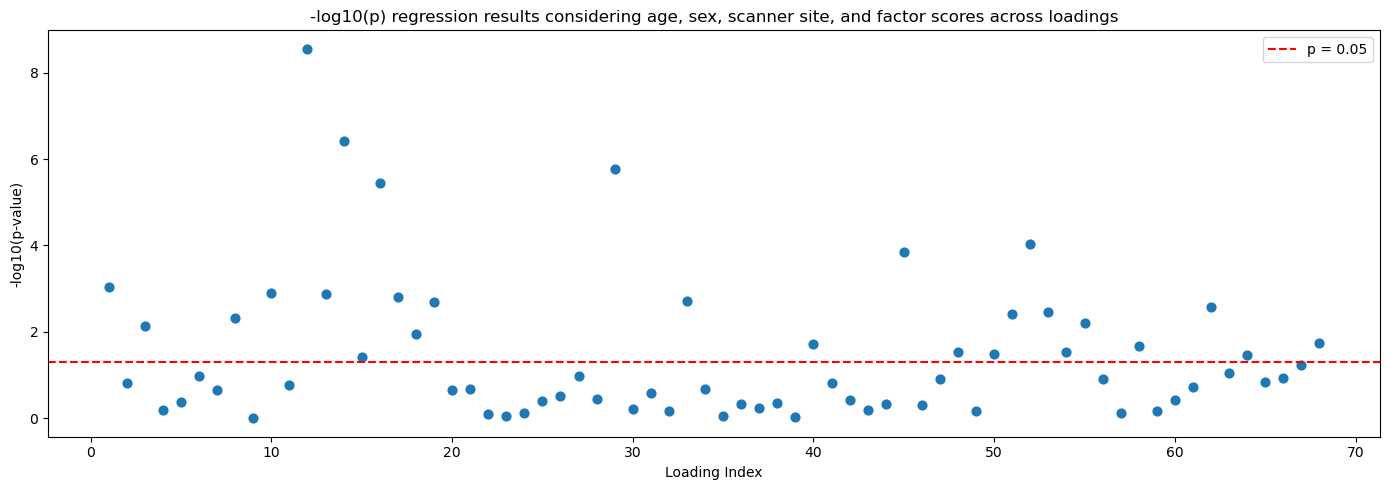

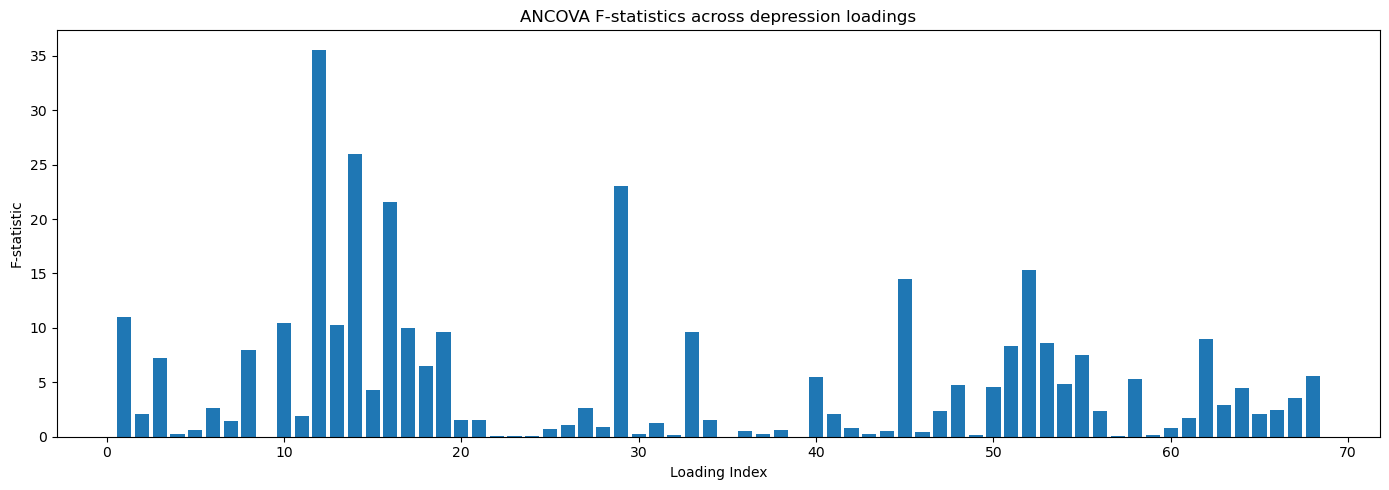

    Loading       p_value     F_stat
0         1  9.115549e-04  11.024713
2         3  7.318587e-03   7.204490
7         8  4.828797e-03   7.956237
9        10  1.266172e-03  10.414159
11       12  2.807374e-09  35.562612
12       13  1.350544e-03  10.294592
13       14  3.745559e-07  25.955769
14       15  3.864835e-02   4.280630
15       16  3.579476e-06  21.571575
16       17  1.597122e-03   9.984245
17       18  1.091374e-02   6.488702
18       19  1.982615e-03   9.585162
28       29  1.685879e-06  23.029926
32       33  1.960888e-03   9.605471
39       40  1.930985e-02   5.480102
44       45  1.434419e-04  14.499756
47       48  2.986605e-02   4.722212
49       50  3.230725e-02   4.587076
50       51  3.839332e-03   8.373450
51       52  9.380844e-05  15.305540
52       53  3.436241e-03   8.575896
53       54  2.850046e-02   4.802927
54       55  6.277762e-03   7.481056
57       58  2.081362e-02   5.348898
61       62  2.707528e-03   9.012207
63       64  3.492541e-02   4.453516
6

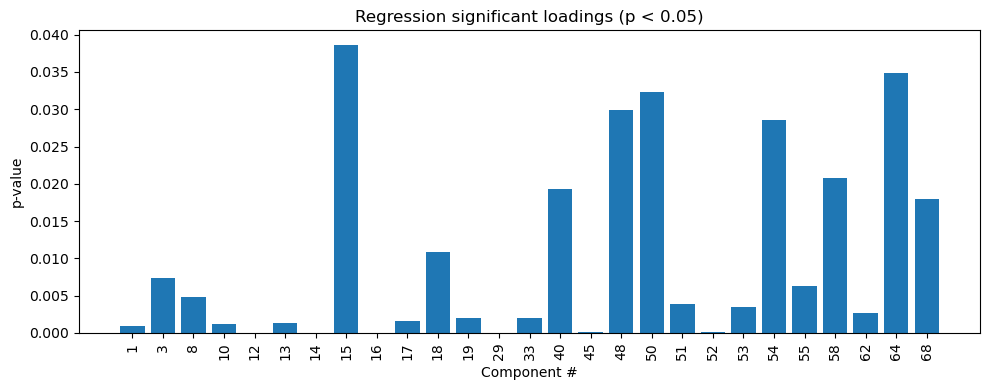

    Loading       p_value     F_stat
0         1  9.115549e-04  11.024713
2         3  7.318587e-03   7.204490
7         8  4.828797e-03   7.956237
9        10  1.266172e-03  10.414159
11       12  2.807374e-09  35.562612
12       13  1.350544e-03  10.294592
13       14  3.745559e-07  25.955769
15       16  3.579476e-06  21.571575
16       17  1.597122e-03   9.984245
18       19  1.982615e-03   9.585162
28       29  1.685879e-06  23.029926
32       33  1.960888e-03   9.605471
44       45  1.434419e-04  14.499756
50       51  3.839332e-03   8.373450
51       52  9.380844e-05  15.305540
52       53  3.436241e-03   8.575896
54       55  6.277762e-03   7.481056
61       62  2.707528e-03   9.012207


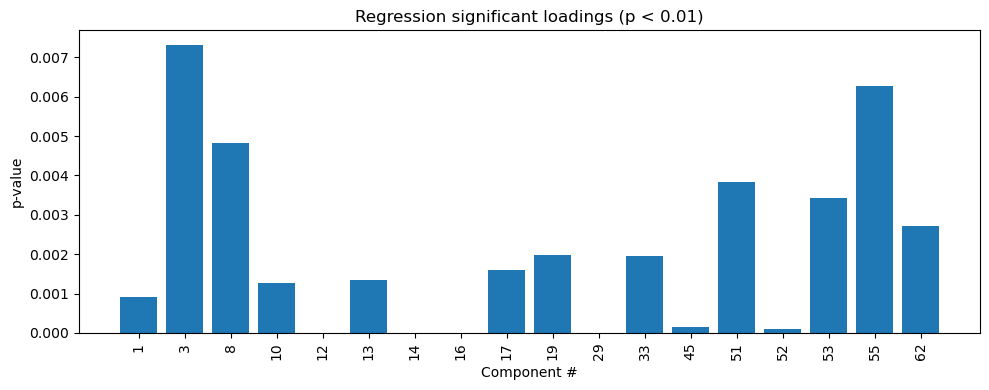

In [137]:
#plot log results

plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["p_value"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="p = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(p-value)")
plt.title("-log10(p) regression results considering age, sex, scanner site, and factor scores across loadings")
plt.legend()
plt.tight_layout()
plt.show()

#plot f stat bar plot
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["F_stat"])
plt.xlabel("Loading Index")
plt.ylabel("F-statistic")
plt.title("ANCOVA F-statistics across depression loadings")
plt.tight_layout()
plt.show()

# highlight sig loadings at p< 0.05

sig = results[results["p_value"] < 0.05]
print(sig)

# Create combined label: "component# - label" with int() to remove .0
sig_labels = [f"{int(row.Loading)}" for _, row in sig.iterrows()]

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["p_value"])

plt.xticks(rotation=90)
plt.title("Regression significant loadings (p < 0.05)")
plt.xlabel("Component #")
plt.ylabel("p-value")
plt.tight_layout()
plt.show()

#now look at p < 0.01

sig = results[results["p_value"] < 0.01]
print(sig)

# Create combined label: "component# - label" with int() to remove .0
sig_labels = [f"{int(row.Loading)}" for _, row in sig.iterrows()]

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["p_value"])

plt.xticks(rotation=90)
plt.title("Regression significant loadings (p < 0.01)")
plt.xlabel("Component #")
plt.ylabel("p-value")
plt.tight_layout()
plt.show()



In [81]:
#run the second regression looking at DepCoM ~ age + sex + site + factor scores 

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np

# all_matrices_dep is 68 x 68 x 2743
# df contains: sex_coded, age, Location_ID,
#              score_c_perc_think_score, score_m_perc_mem_work_score

results = []

# Loop over upper triangle only (j > i)
for i in range(68):
    for j in range(i + 1, 68):

        # Extract subject-level CoM values for this edge (length 2743)
        df["CoM_val"] = all_matrices_dep[i, j, :]

        # Regression formula
        formula = (
            "CoM_val ~ age + C(sex_coded) + C(Location_ID) + "
            "score_c_perc_think_score + score_m_perc_mem_work_score"
        )

        # Fit model
        model = ols(formula, data=df).fit()
        anova = sm.stats.anova_lm(model, typ=2)

        # Extract p-value and F-stat for the predictor of interest
        p = float(anova.loc["score_c_perc_think_score", "PR(>F)"])
        F = float(anova.loc["score_c_perc_think_score", "F"])

        # Store results
        results.append([i+1, j+1, p, F])

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Row", "Col", "p_value", "F_stat"])

print(results_df)


      Row  Col   p_value    F_stat
0       1    2  0.037131  4.348896
1       1    3  0.324279  0.971979
2       1    4  0.047872  3.918201
3       1    5  0.332724  0.938619
4       1    6  0.010644  6.533401
...   ...  ...       ...       ...
2273   65   67  0.006580  7.396225
2274   65   68  0.265848  1.238584
2275   66   67  0.029308  4.754695
2276   66   68  0.066768  3.363582
2277   67   68  0.905963  0.013958

[2278 rows x 4 columns]


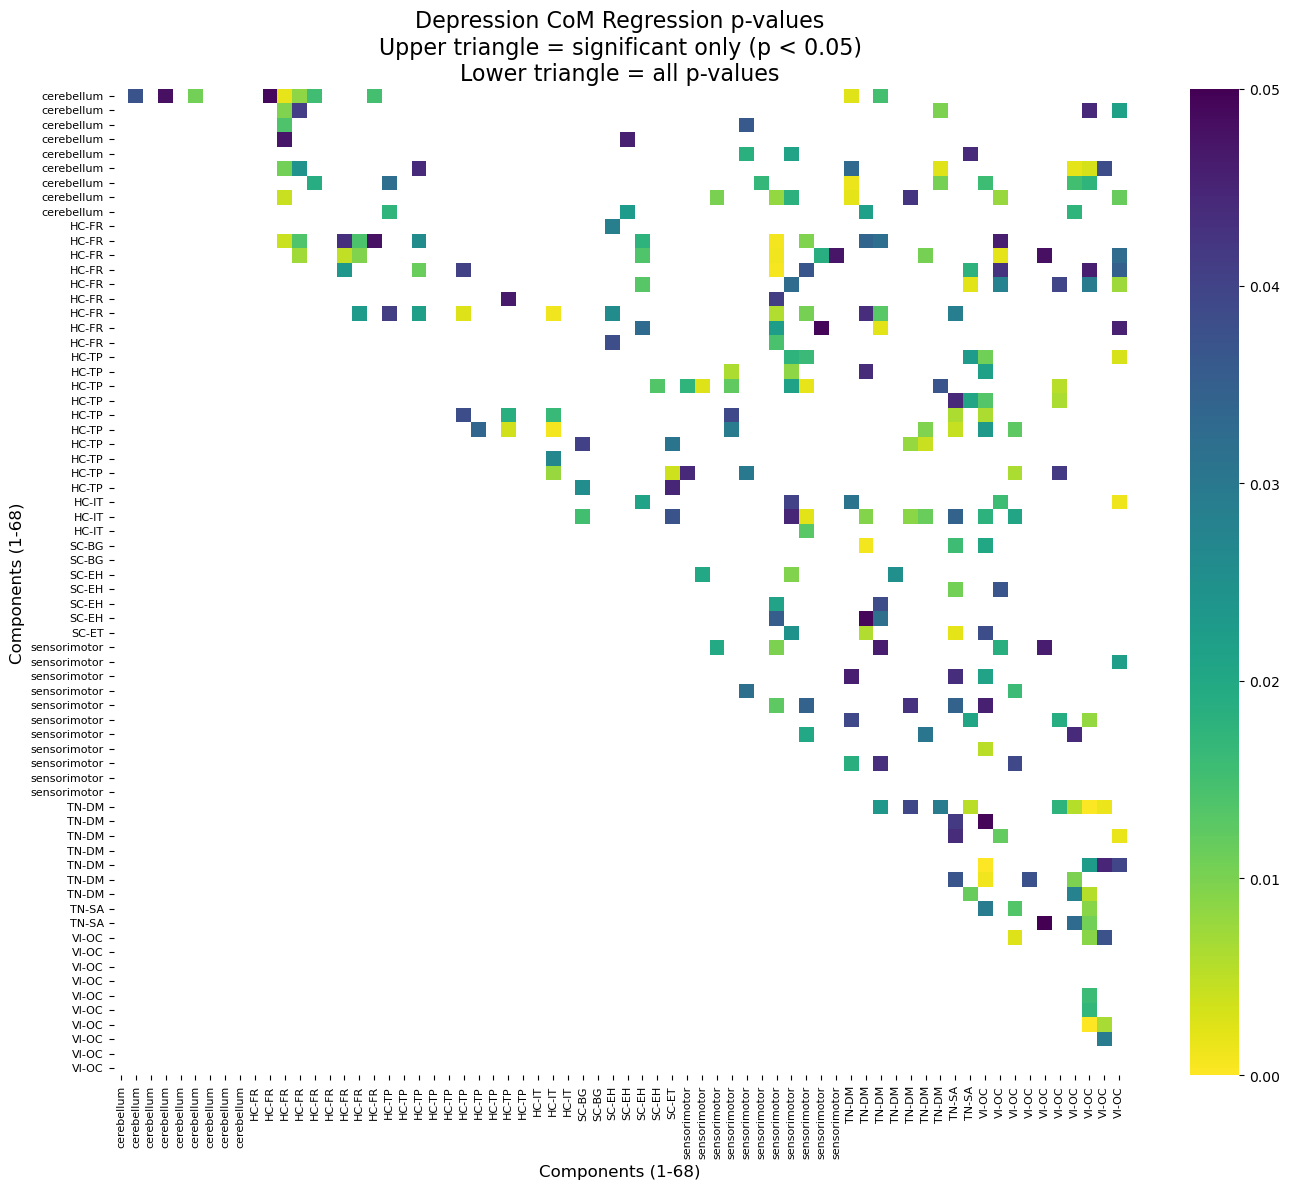

In [105]:
# --- Build asymmetric p-value matrix for plotting ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Labels to a clean Python list of strings
# This removes dtype info and array formatting
# Ensure Labels is a flat list of pure Python strings

# initialize matrix with NaNs
p_matrix = np.full((68, 68), np.nan)

# --- LOWER TRIANGLE: fill with ALL p-values ---
for _, row in results_df.iterrows():
    i = int(row["Row"]) - 1
    j = int(row["Col"]) - 1
    p = row["p_value"]

    if j < i:   # lower triangle
        p_matrix[i, j] = p

# --- UPPER TRIANGLE: fill ONLY significant p-values ---
for _, row in results_df.iterrows():
    i = int(row["Row"]) - 1
    j = int(row["Col"]) - 1
    p = row["p_value"]

    if j > i:   # upper triangle
        if p < 0.05:
            p_matrix[i, j] = p
        else:
            p_matrix[i, j] = np.nan   # mask non-significant values

# diagonal stays NaN
np.fill_diagonal(p_matrix, np.nan)

# --- Plot heatmap with clean Labels ---

plt.figure(figsize=(14, 12))
ax = sns.heatmap(
    p_matrix,
    cmap="viridis_r",
    vmin=0,
    vmax=0.05,
    mask=np.isnan(p_matrix)
)

plt.title(
    "Depression CoM Regression p-values\n"
    "Upper triangle = significant only (p < 0.05)\n"
    "Lower triangle = all p-values",
    fontsize=16
)

# Apply Labels to ticks
plt.xticks(
    ticks=np.arange(68) + 0.5,
    labels=clean_labels, #use updated labels variable
    rotation=90,
    fontsize=8
)

plt.yticks(
    ticks=np.arange(68) + 0.5,
    labels=clean_labels, #use updated labels variable
    rotation=0,
    fontsize=8
)

plt.xlabel("Components (1-68)", fontsize=12)
plt.ylabel("Components (1-68)", fontsize=12)
plt.tight_layout()
plt.show()